<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-03/trabalho-03/svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Equipe**: 01<br>
> **Estudantes**: Cristina Siewert Jansen, Marlon Sbardelatti e Sofia Sousa Lindner

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# PARTE 4: SVM

**1. Aplique o algoritmo SVM na base de dados ‘credit.pkl’.**

In [2]:
import pickle

# Abrir o arquivo
with open('credit.pkl', 'rb') as f:
  X_credit_train, y_credit_train, X_credit_test, y_credit_test = pickle.load(f)

**2. Inicialmente treine o SVM com kernel linear, valor do parâmetro C = 1.0 e ‘random_state =1’.**

In [3]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', C=1.0, random_state=1)

svm_linear.fit(X_credit_train, y_credit_train)

SVC(kernel='linear', random_state=1)

**3. Utilize o comando do sklearn accuray_score para calcular a acurácia do seu algoritmo. O resultado deve ser 0.946.**

In [4]:
from sklearn.metrics import accuracy_score

y_predictions_linear = svm_linear.predict(X_credit_test)
accuracy_score(y_credit_test, y_predictions_linear)

0.946

**4. Teste os demais kernels e anote os resultados. Qual o melhor kernel para a sua base de dados?**
- **Polinomial**
- **Sigmoide**
- **rbf**

In [34]:
KERNEL_TYPES = ['poly', 'sigmoid', 'rbf']

for kernel in KERNEL_TYPES:
  svm = SVC(kernel=kernel, C=1.0, random_state=1)

  svm.fit(X_credit_train, y_credit_train)

  y_predictions = svm.predict(X_credit_test)

  accuracy = accuracy_score(y_credit_test, y_predictions)

  print(f'Acurácia do kernel {kernel}: {accuracy}')

Acurácia do kernel poly: 0.968
Acurácia do kernel sigmoid: 0.838
Acurácia do kernel rbf: 0.982


O melhor kernel é o radial basis function (RBF), com 98,2% de acurácia, seguido do polinomial (96,8%), e o de pior desempenho é o sigmoide, com acurácia de 83,8%.

**5. Aumente o valor do parâmetro C aplicado ao melhor kernel e verifique se há mudanças no resultado do seu SVM.**

In [12]:
# Usar escala logarítmica de base 10
C_SIZE = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for c in C_SIZE:
  svm_poly = SVC(kernel='rbf', C=c, random_state=1)

  svm_poly.fit(X_credit_train, y_credit_train)

  y_predictions_poly = svm_poly.predict(X_credit_test)

  accuracy = accuracy_score(y_credit_test, y_predictions_poly)

  print(f'Acurácia para c = {c}: {accuracy}')

Acurácia para c = 0.001: 0.872
Acurácia para c = 0.01: 0.872
Acurácia para c = 0.1: 0.966
Acurácia para c = 1: 0.982
Acurácia para c = 10: 0.988
Acurácia para c = 100: 0.99
Acurácia para c = 1000: 0.988


O valor do hiperparâmetro C igual a 100 levou à maior acurácia (99%). Valores inferiores e superiores a esse geraram acurácias menores.

**6. O Grid Search (pesquisa em grade) é uma técnica utilizada para melhorar a precisão e a generalização dos modelos de aprendizado de máquina. Ela é usada para realizar ajustes de hiperparâmetros durante o treinamento de um modelo. O grid search automatiza o processo de encontrar hiperparâmetros ideais, economizando esforço humano em comparação com o ajuste manual, mas pode até ser mais custoso do ponto de vista de desempenho, pois testa todas as combinações possíveis e retorna a que obteve melhor desempenho.
Agora, aplique o GridSearch do Scikit-Learn (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) para ajudar a identificar os melhores hiperparâmetros para o seu modelo. Qual foi a melhor combinação de hiperparâmetros encontrada? O modelo com melhor desempenho foi obtido com os parâmetros ajustados manualmente ou com o GridSearch?**

In [29]:
from sklearn.model_selection import GridSearchCV

# Especificar valores de parâmetros possíveis
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'kernel': ['poly', 'sigmoid', 'rbf']
}

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5)

grid_search.fit(X_credit_train, y_credit_train)

print(f'Melhor combinação de hiperparâmetros: {grid_search.best_params_}')
print(f'Melhor acurácia média encontrada no CV: {grid_search.best_score_}')

Melhor combinação de hiperparâmetros: {'C': 1000, 'kernel': 'rbf'}
Melhor acurácia média encontrada no CV: 0.9933333333333334


A aplicação da pesquisa em grade retornou como melhor modelo aquele contendo kernel RBF e valor de C igual a 1000, com acurácia de 99,3%.

Nos testes manuais, o melhor kernel também foi o RBF, mas o valor ótimo de C obtido foi diferente. Para C=100, a acurácia foi de 99% e para C=1000, 98,8%.

Decidiu-se aplicar o melhor modelo retornado pelo GridSearch nos dados de teste do dataset de crédito.

In [33]:
# Aplicar o melhor modelo ao problema real
best_model = grid_search.best_estimator_

y_predictions_best = best_model.predict(X_credit_test)

best_accuracy = accuracy_score(y_credit_test, y_predictions_best)

print(f'Acurácia do melhor modelo no teste: {best_accuracy}')

Acurácia do melhor modelo no teste: 0.988


Ao aplicar o melhor modelo apontado pelo GridSearch nos dados de teste, obteve-se uma acurácia 98,8%, da mesma forma que os testes manuais anteriores.
Deduziu-se que isso se deve ao fato da pontuação do GridSearch ser calculada sobre a acurácia das cross-validations, e quando o modelo é aplicado ao conjunto de teste, seu desempenho pode não se manter (no caso de overfitting, por exemplo).
Dessa forma, o melhor resultado para o problema real foi encontrado nos testes manuais.


# Análise dos resultados dos 4 algoritmos utilizados

**7. O resultado do SVM é melhor que os resultados do Naive Bayes, Florestas Aleatórias e Regressão Logística? Descreva sua análise de resultados (observe que para isso você deverá visualizar os resultados da Matriz de Confusão, acurácia, precisão e recall).**

In [36]:
from sklearn.metrics import accuracy_score

# Função utilitária para exibir erros em relação ao total e calcular acurácia
def calculate_accuracy(expected: np.ndarray, predictions: np.ndarray):
  count_diff = 0
  total = len(predictions)
  for i in range(total):
    if predictions[i] != expected[i]:
      count_diff += 1

  print(f'Previsões corretas:  {total - count_diff}/{total}')
  print(f'Previsões incorretas: {count_diff}/{total}')
  print(f'Acurácia: {accuracy_score(expected, predictions)}')

In [37]:
svm = SVC(kernel='rbf', C=100, random_state=1)

svm.fit(X_credit_train, y_credit_train)

y_predictions = svm.predict(X_credit_test)

calculate_accuracy(y_credit_test, y_predictions)

Previsões corretas:  495/500
Previsões incorretas: 5/500
Acurácia: 0.99


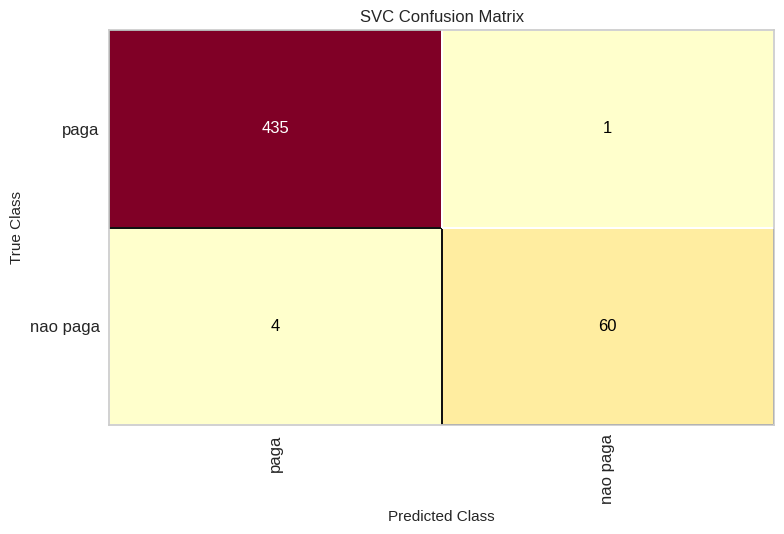

In [40]:
from yellowbrick.classifier import ConfusionMatrix

CLASS_NAMES = ['paga', 'nao paga']

cm = ConfusionMatrix(svm, classes=CLASS_NAMES)
cm.fit(X_credit_train, y_credit_train)
cm.score(X_credit_test, y_credit_test)
cm.show()

plt.show()

In [42]:
from sklearn.metrics import classification_report

test_report = classification_report(
  y_credit_test,
  y_predictions,
  target_names=CLASS_NAMES
)

print(f'Relatório com métricas: \n{test_report}')

Relatório com métricas: 
              precision    recall  f1-score   support

        paga       0.99      1.00      0.99       436
    nao paga       0.98      0.94      0.96        64

    accuracy                           0.99       500
   macro avg       0.99      0.97      0.98       500
weighted avg       0.99      0.99      0.99       500



Tanto no valor de acurácia quanto na métrica considerada mais relevante no contexto, o SVM teve o melhor desempenho.

Quanto aos acertos gerais, o SVM teve 99% de acurácia, superando a da Random Forest (98,4%). Em todos os casos do relatório de classificação percebe-se uma taxa relativamente alta de acerto. No caso do recall para a classe "nao paga", apontado anteriormente como a situação de maior peso, o desempenho do SVM foi superior ao anterior: 94%.